# Phase 2 Vision Scratch Notebook

This notebook is the first Phase 2 sanity check. The goal is simple: prove that the Phase 1 manifest can be used for vision modelling before building any model code.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Load The Manifest

Load the final Phase 1 manifest. This table connects each cleaned X-ray image to its labels and train/val/test split.

In [2]:
PROJECT_ROOT = Path("..").resolve()
manifest_path = PROJECT_ROOT / "data" / "processed" / "manifest.parquet"

df = pd.read_parquet(manifest_path)
df.shape

(3791, 11)

In [3]:
df.head()

,image_id,image_path,patient_id,study_id,report_findings,report_impression,labels,split,projection,report_indication,report_text
0,1_IM-0001-4001.dcm,data/processed/images_224/1_IM-0001-4001.dcm.png,1,1,The cardiac silhouette and mediastinum size ar...,Normal chest x- .,[No Finding],test,Frontal,Positive TB test,The cardiac silhouette and mediastinum size ar...
1,1009_IM-0010-1001.dcm,data/processed/images_224/1009_IM-0010-1001.dc...,1009,1009,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,[No Finding],test,Frontal,786.50 anterior left sided chest pain,The cardiomediastinal silhouette and pulmonary...
2,1010_IM-0012-1001.dcm,data/processed/images_224/1010_IM-0012-1001.dc...,1010,1010,Cardiac and mediastinal contours are within no...,Negative chest x- .,[No Finding],test,Frontal,.,Cardiac and mediastinal contours are within no...
3,1018_IM-0014-5001.dcm,data/processed/images_224/1018_IM-0014-5001.dc...,1018,1018,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,[Other],test,Frontal,,The cardiomediastinal silhouette and pulmonary...
4,1020_IM-0017-1001.dcm,data/processed/images_224/1020_IM-0017-1001.dc...,1020,1020,Lung volumes are low. No focal infiltrates. He...,Hypoinflation with no visible active cardiopul...,[Other],test,Frontal,chest pain,Lung volumes are low. No focal infiltrates. He...


## Define The Model Labels

The vision model predicts only the 6 disease findings. No Finding and Other are not model outputs.

In [4]:
DISEASE_LABELS = [
    "Cardiomegaly",
    "Atelectasis",
    "Consolidation / Pneumonia",
    "Pleural Effusion",
    "Edema",
    "Pneumothorax",
]

DISEASE_LABELS

['Cardiomegaly',
 'Atelectasis',
 'Consolidation / Pneumonia',
 'Pleural Effusion',
 'Edema',
 'Pneumothorax']

## Check The Splits

Confirm the train, validation, and test rows are present before any model work.

In [5]:
df["split"].value_counts()

split
train    2653
val       574
test      564
Name: count, dtype: int64

## Pick One Example Row

Use one row to check the image path, labels, and report text by hand.

In [6]:
row = df.iloc[0]

row["image_path"], row["labels"], row["report_text"][:300]

('data/processed/images_224/1_IM-0001-4001.dcm.png',
 array(['No Finding'], dtype=object),
 'The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no of a pleural effusion. There is no evidence of pneumothorax.')

## Open One Image

Open the cleaned 224 x 224 image from image_path. If this works, the manifest paths are usable for a PyTorch Dataset later.

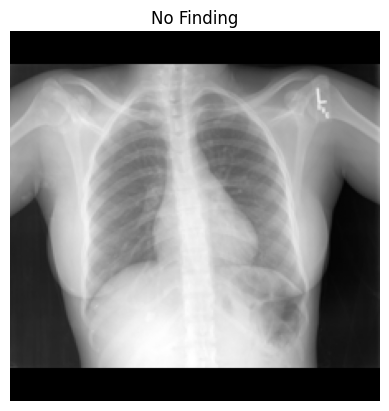

(224, 224)

In [7]:
image_path = PROJECT_ROOT / Path(row["image_path"])
img = Image.open(image_path).convert("L")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(", ".join(row["labels"]))
plt.show()

img.size

## Make One Multi-Hot Target

Convert the row labels into a 6-number target vector. A 1 means that disease is present. A 0 means it is absent.

In [8]:
target = [1 if label in row["labels"] else 0 for label in DISEASE_LABELS]
target

[0, 0, 0, 0, 0, 0]

## Show The Target Clearly

Display the target vector beside the disease names so it is easy to check.

In [9]:
pd.DataFrame({
    "label": DISEASE_LABELS,
    "target": target
})

,label,target
0,Cardiomegaly,0
1,Atelectasis,0
2,Consolidation / Pneumonia,0
3,Pleural Effusion,0
4,Edema,0
5,Pneumothorax,0


## Check A Few Rows

Sample a few studies and print their original labels beside the 6-number target vector. This helps confirm the target logic is not backwards.

In [10]:
sample = df.sample(5, random_state=1)

for _, row in sample.iterrows():
    target = [1 if label in row["labels"] else 0 for label in DISEASE_LABELS]
    print(row["study_id"])
    print(row["labels"])
    print(target)
    print("-" * 50)

2188
['Other']
[0, 0, 0, 0, 0, 0]
--------------------------------------------------
3347
['Other']
[0, 0, 0, 0, 0, 0]
--------------------------------------------------
3181
['No Finding']
[0, 0, 0, 0, 0, 0]
--------------------------------------------------
2775
['No Finding']
[0, 0, 0, 0, 0, 0]
--------------------------------------------------
3008
['No Finding']
[0, 0, 0, 0, 0, 0]
--------------------------------------------------


## Create A Helper Function

This function is the small piece of logic that will later move into src/models/dataset.py.

In [11]:
def make_target(labels):
    return [1 if label in labels else 0 for label in DISEASE_LABELS]

## Apply Targets To The Manifest

Create a target column so every row has a model-ready label vector.

In [12]:
df["target"] = df["labels"].apply(make_target)

df[["labels", "target"]].head()

,labels,target
0,[No Finding],"[0, 0, 0, 0, 0, 0]"
1,[No Finding],"[0, 0, 0, 0, 0, 0]"
2,[No Finding],"[0, 0, 0, 0, 0, 0]"
3,[Other],"[0, 0, 0, 0, 0, 0]"
4,[Other],"[0, 0, 0, 0, 0, 0]"


## Show Sample Images With Targets

Display a few images with their target vectors. This checks that image loading and labels line up visually.

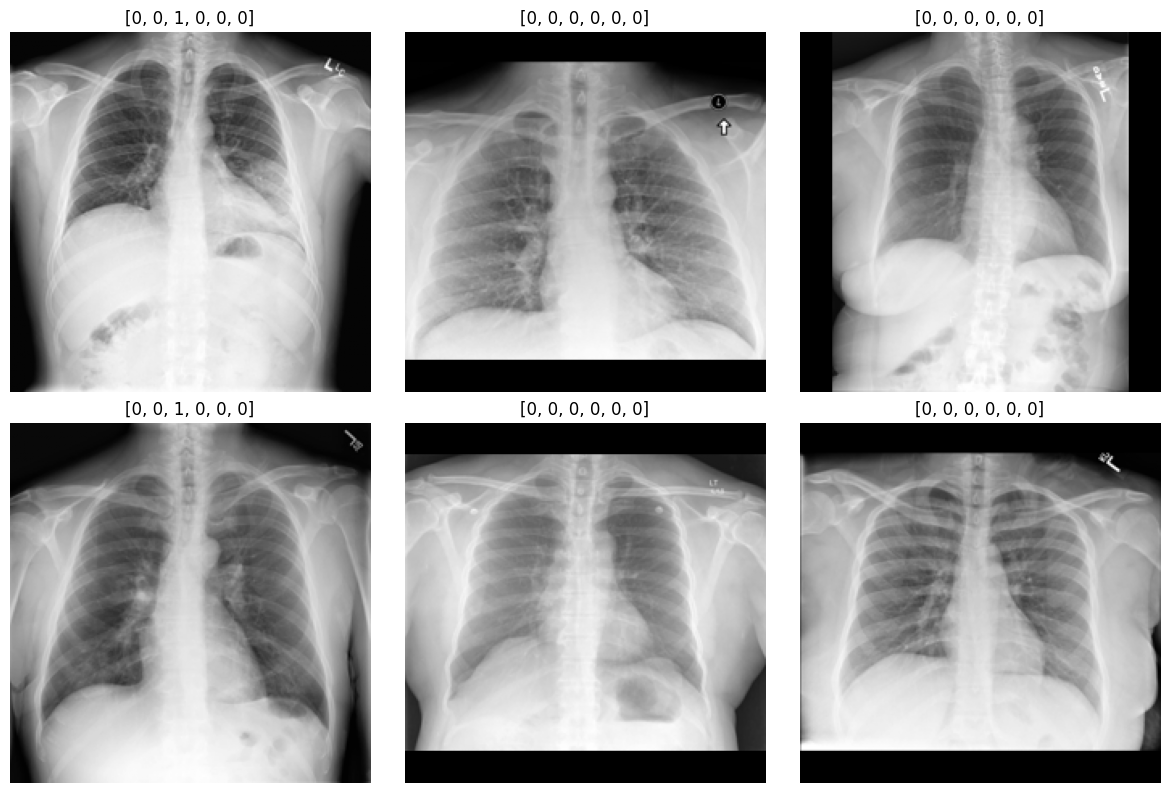

In [13]:
sample = df.sample(6, random_state=2)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    image_path = PROJECT_ROOT / Path(str(row["image_path"]).replace("\\", "/"))
    img = Image.open(image_path).convert("L")
    
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(str(row["target"]))

plt.tight_layout()
plt.show()

## Count Disease Labels Per Split

These counts show class imbalance. The rare classes, especially Edema and Pneumothorax, will need careful reporting in evaluation.

In [14]:
for split in ["train", "val", "test"]:
    part = df[df["split"] == split]
    print(split, len(part))
    print(pd.DataFrame(part["target"].tolist(), columns=DISEASE_LABELS).sum())
    print("-" * 50)

train 2653
Cardiomegaly                 228
Atelectasis                  217
Consolidation / Pneumonia    138
Pleural Effusion             106
Edema                         35
Pneumothorax                  17
dtype: int64
--------------------------------------------------
val 574
Cardiomegaly                 57
Atelectasis                  44
Consolidation / Pneumonia    29
Pleural Effusion             18
Edema                         7
Pneumothorax                  3
dtype: int64
--------------------------------------------------
test 564
Cardiomegaly                 45
Atelectasis                  47
Consolidation / Pneumonia    30
Pleural Effusion             23
Edema                         2
Pneumothorax                  3
dtype: int64
--------------------------------------------------


## What I Checked

- The manifest loads correctly.
- Images open from image_path.
- Each row can become a 6-number multi-hot target.
- No Finding and Other are not model outputs.
- Train/val/test splits are available.
- Edema and Pneumothorax are rare, so their later metrics must be treated carefully.

Conclusion: the dataset is ready for the next notebook step, which is the pretrained baseline.